# Unsupervised Plant Leaf Disease Segmentation using Gaussian Mixture Model (GMM)

This section performs **unsupervised disease-region segmentation** on plant leaf images using a **Gaussian Mixture Model (GMM)**. The model clusters leaf pixels based on their color characteristics in **LAB and HSV color spaces** and identifies the cluster corresponding to diseased regions.

### Input Image Assumption

The images used in this experiment are **already leaf-segmented**, meaning the background has been removed and represented by **black pixels**. Therefore, black background pixels are ignored and only the leaf pixels are provided to the GMM.

If the input image is **not already leaf-segmented**, the background should first be separated from the leaf. In that case, when using GMM directly for pixel clustering, `N_COMPONENTS = 3` can be used to represent three possible pixel distributions:

1. Background
2. Healthy leaf tissue
3. Diseased leaf regions

For the current leaf-segmented images, the background is already removed, so `N_COMPONENTS = 2` is used to separate the two main distributions: **healthy and diseased leaf tissue**.

### Feature Extraction

For every leaf pixel, six color features are extracted:

`[L, a, b, H, S, V]`

where the first three features come from the **LAB** color space and the remaining three from **HSV**. These features are standardized before being provided to the GMM.

### Segmentation Pipeline

**Leaf Image → LAB + HSV Features → Standardization → GMM Clustering → Disease Cluster Selection → Probability Thresholding → Morphological Cleanup → Final Disease Mask**

The disease cluster is selected using the mean value of the LAB `a` channel as a heuristic, since diseased/brown regions generally exhibit different color characteristics from healthy green leaf tissue. The resulting disease mask is cleaned using morphological operations and connected-component filtering.

Finally, the detected disease region is overlaid on the original image and the **disease severity (%)** is estimated from the ratio of detected disease pixels to total leaf pixels.

### Dataset

The experiments use the **PlantVillage Dataset (Labeled)** available on Kaggle:

https://www.kaggle.com/datasets/soumiknafiul/plantvillage-dataset-labeled

> **Note:** GMM is an unsupervised clustering method and does not inherently know which cluster represents disease. The disease-cluster selection used here is a heuristic based on color characteristics.


GMM CLUSTER STATISTICS
Cluster 0: Pixels= 11205 | L= 113.38 | a= 124.78 | b= 153.35
Cluster 1: Pixels= 26121 | L= 166.76 | a= 110.41 | b= 178.32


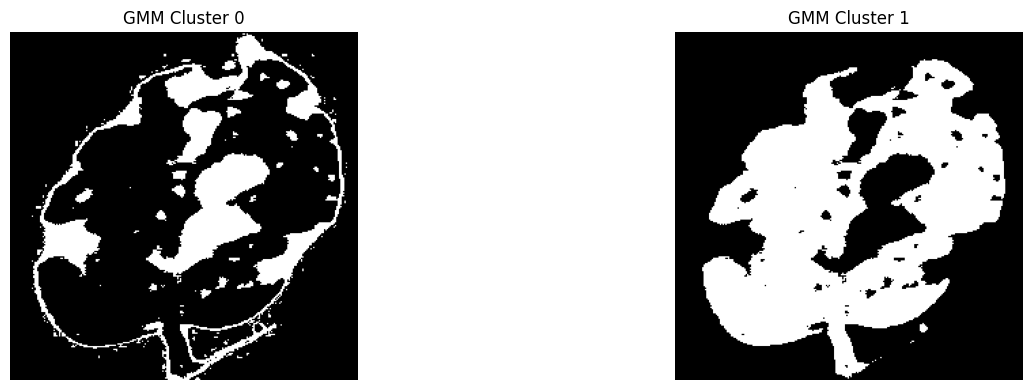

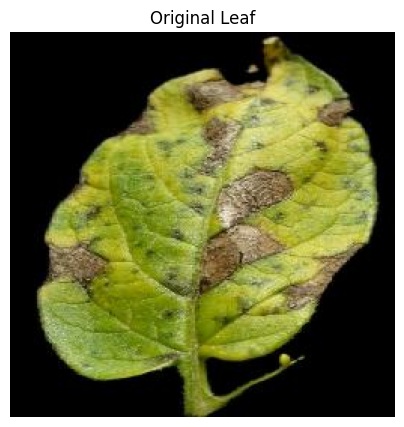

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. LOAD IMAGE
# ============================================================

image_path = "/kaggle/input/datasets/soumiknafiul/plantvillage-dataset-labeled/PlantVillage Dataset (Labeled)/Segmented Images/Potato___Early_blight/07953ca1-8935-449f-b338-4357ed683b2d___RS_Early.B 6815_final_masked.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ============================================================
# 2. CREATE LEAF-PIXEL MASK
#    Your background is already black, so we simply ignore it.
# ============================================================

leaf_mask = np.any(image > 10, axis=2)

# ============================================================
# 3. CONVERT RGB -> LAB
# ============================================================

lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float32)

# Only use pixels belonging to the leaf
X = lab[leaf_mask]

# ============================================================
# 4. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 5. TRAIN GMM
# ============================================================

N_COMPONENTS = 2

gmm = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type="full",
    n_init=5,
    random_state=42
)

gmm.fit(X_scaled)

# ============================================================
# 6. PREDICT CLUSTERS
# ============================================================

labels = gmm.predict(X_scaled)

# Put cluster labels back into image shape
cluster_map = np.full(
    leaf_mask.shape,
    -1,
    dtype=np.int32
)

cluster_map[leaf_mask] = labels

# ============================================================
# 7. PRINT CLUSTER STATISTICS
# ============================================================

print("\nGMM CLUSTER STATISTICS")
print("=" * 60)

for cluster in range(N_COMPONENTS):

    pixels = X[labels == cluster]

    print(
        f"Cluster {cluster}: "
        f"Pixels={len(pixels):6d} | "
        f"L={pixels[:,0].mean():7.2f} | "
        f"a={pixels[:,1].mean():7.2f} | "
        f"b={pixels[:,2].mean():7.2f}"
    )

# ============================================================
# 8. SHOW GMM CLUSTERS
# ============================================================

fig, axes = plt.subplots(
    1,
    N_COMPONENTS,
    figsize=(16, 4)
)

for cluster in range(N_COMPONENTS):

    mask = cluster_map == cluster

    axes[cluster].imshow(mask, cmap="gray")
    axes[cluster].set_title(f"GMM Cluster {cluster}")
    axes[cluster].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 9. SHOW ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Original Leaf")
plt.axis("off")
plt.show()

Number of leaf pixels: 33657
Feature shape: (33657, 6)

GMM CLUSTER STATISTICS

Cluster 0
  Pixels : 5404
  Lab    : L=103.67, a=115.76, b=148.63
  HSV    : H=0.229, S=0.484, V=0.408

Cluster 1
  Pixels : 28253
  Lab    : L=129.91, a=108.85, b=150.02
  HSV    : H=0.270, S=0.368, V=0.508

Automatically selected disease cluster: 0


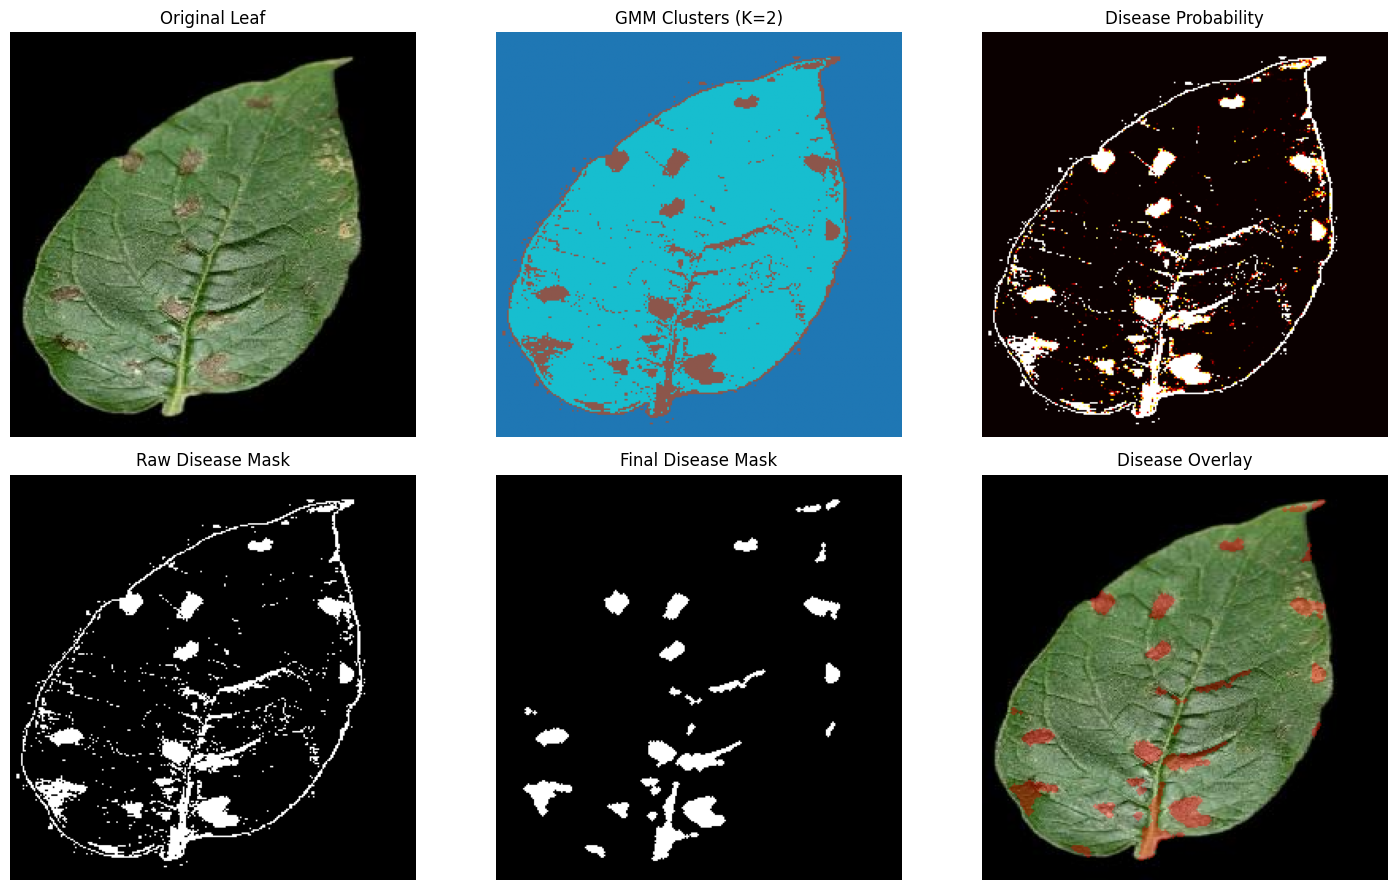


RESULT
Leaf pixels    : 33657
Disease pixels : 3059
Disease area   : 9.09%


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_PATH ="/kaggle/input/datasets/soumiknafiul/plantvillage-dataset-labeled/PlantVillage Dataset (Labeled)/Segmented Images/Potato___Early_blight/04c8e6b9-7710-4cdd-b259-2d78b15d1036___RS_Early.B 7066_final_masked.jpg"
N_COMPONENTS = 2

# GMM settings
N_INIT = 10
RANDOM_STATE = 42

# Probability threshold
# Higher = stricter disease mask
PROBABILITY_THRESHOLD = 0.50

# Morphological cleanup
MORPH_KERNEL_SIZE = 3

# Remove very small connected components
MIN_REGION_SIZE = 20


# ============================================================
# 1. LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

H, W, _ = image.shape


# ============================================================
# 2. EXISTING LEAF MASK
# ============================================================
# Your background is already black.
# We DON'T perform leaf segmentation.
# We simply ignore black background pixels.

leaf_mask = np.any(image > 10, axis=2)


# ============================================================
# 3. CREATE COLOR FEATURES
# ============================================================

# RGB -> LAB
lab = cv2.cvtColor(
    image,
    cv2.COLOR_RGB2LAB
).astype(np.float32)

# RGB -> HSV
hsv = cv2.cvtColor(
    image,
    cv2.COLOR_RGB2HSV
).astype(np.float32)


# Normalize OpenCV HSV ranges
hsv[:, :, 0] /= 179.0
hsv[:, :, 1] /= 255.0
hsv[:, :, 2] /= 255.0


# Extract only leaf pixels
lab_pixels = lab[leaf_mask]
hsv_pixels = hsv[leaf_mask]


# ============================================================
# 4. COMBINE FEATURES
# ============================================================

# Each pixel:
#
# [L, a, b, H, S, V]
#
X = np.concatenate(
    [lab_pixels, hsv_pixels],
    axis=1
)

print("Number of leaf pixels:", len(X))
print("Feature shape:", X.shape)


# ============================================================
# 5. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 6. TRAIN GMM
# ============================================================

gmm = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type="full",
    n_init=N_INIT,
    random_state=RANDOM_STATE
)

gmm.fit(X_scaled)


# ============================================================
# 7. GET CLUSTER PROBABILITIES
# ============================================================

probabilities = gmm.predict_proba(X_scaled)

labels = np.argmax(probabilities, axis=1)


# ============================================================
# 8. RECONSTRUCT CLUSTER MAP
# ============================================================

cluster_map = np.full(
    (H, W),
    -1,
    dtype=np.int32
)

cluster_map[leaf_mask] = labels


# ============================================================
# 9. DISPLAY CLUSTER STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("GMM CLUSTER STATISTICS")
print("=" * 70)

for cluster in range(N_COMPONENTS):

    cluster_pixels = X[labels == cluster]

    mean_L = cluster_pixels[:, 0].mean()
    mean_a = cluster_pixels[:, 1].mean()
    mean_b = cluster_pixels[:, 2].mean()

    mean_H = cluster_pixels[:, 3].mean()
    mean_S = cluster_pixels[:, 4].mean()
    mean_V = cluster_pixels[:, 5].mean()

    print(
        f"\nCluster {cluster}"
    )

    print(
        f"  Pixels : {len(cluster_pixels)}"
    )

    print(
        f"  Lab    : "
        f"L={mean_L:.2f}, "
        f"a={mean_a:.2f}, "
        f"b={mean_b:.2f}"
    )

    print(
        f"  HSV    : "
        f"H={mean_H:.3f}, "
        f"S={mean_S:.3f}, "
        f"V={mean_V:.3f}"
    )


# ============================================================
# 10. AUTOMATICALLY SELECT DISEASE CLUSTER
# ============================================================
#
# Disease/brown regions generally have a higher Lab 'a'
# value than healthy green tissue.
#
# Therefore we select the cluster having the highest
# mean 'a' value.
#
# IMPORTANT:
# This is a heuristic, not something GMM itself knows.

cluster_a_means = []

for cluster in range(N_COMPONENTS):

    cluster_pixels = X[labels == cluster]

    mean_a = cluster_pixels[:, 1].mean()

    cluster_a_means.append(mean_a)


disease_cluster = np.argmax(cluster_a_means)

print("\nAutomatically selected disease cluster:",
      disease_cluster)


# ============================================================
# 11. DISEASE PROBABILITY MAP
# ============================================================

disease_probability = probabilities[:, disease_cluster]

probability_map = np.zeros(
    (H, W),
    dtype=np.float32
)

probability_map[leaf_mask] = disease_probability


# ============================================================
# 12. RAW DISEASE MASK
# ============================================================

disease_mask = (
    probability_map >= PROBABILITY_THRESHOLD
).astype(np.uint8)


# Never classify background as disease
disease_mask[~leaf_mask] = 0


# ============================================================
# 13. MORPHOLOGICAL CLEANUP
# ============================================================

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (
        MORPH_KERNEL_SIZE,
        MORPH_KERNEL_SIZE
    )
)

# Remove small holes / connect nearby pixels
clean_mask = cv2.morphologyEx(
    disease_mask,
    cv2.MORPH_OPEN,
    kernel
)

clean_mask = cv2.morphologyEx(
    clean_mask,
    cv2.MORPH_CLOSE,
    kernel
)


# ============================================================
# 14. REMOVE VERY SMALL CONNECTED COMPONENTS
# ============================================================

num_labels, component_labels, stats, centroids = cv2.connectedComponentsWithStats(
    clean_mask,
    connectivity=8
)

final_mask = np.zeros_like(clean_mask)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area >= MIN_REGION_SIZE:

        final_mask[component_labels == i] = 1


# ============================================================
# 15. CREATE OVERLAY
# ============================================================

overlay = image.copy()

# Red overlay for detected disease
overlay[final_mask == 1] = [255, 0, 0]

# Blend original + disease overlay
result = cv2.addWeighted(
    image,
    0.65,
    overlay,
    0.35,
    0
)


# ============================================================
# 16. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


# Original
axes[0, 0].imshow(image)
axes[0, 0].set_title("Original Leaf")
axes[0, 0].axis("off")


# Cluster map
axes[0, 1].imshow(
    cluster_map,
    cmap="tab10"
)

axes[0, 1].set_title(
    f"GMM Clusters (K={N_COMPONENTS})"
)

axes[0, 1].axis("off")


# Disease probability
axes[0, 2].imshow(
    probability_map,
    cmap="hot",
    vmin=0,
    vmax=1
)

axes[0, 2].set_title(
    "Disease Probability"
)

axes[0, 2].axis("off")


# Raw disease mask
axes[1, 0].imshow(
    disease_mask,
    cmap="gray"
)

axes[1, 0].set_title(
    "Raw Disease Mask"
)

axes[1, 0].axis("off")


# Clean mask
axes[1, 1].imshow(
    final_mask,
    cmap="gray"
)

axes[1, 1].set_title(
    "Final Disease Mask"
)

axes[1, 1].axis("off")


# Overlay
axes[1, 2].imshow(result)

axes[1, 2].set_title(
    "Disease Overlay"
)

axes[1, 2].axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# 17. DISEASE SEVERITY
# ============================================================

leaf_area = np.sum(leaf_mask)

disease_area = np.sum(final_mask)

severity = (
    disease_area / leaf_area
) * 100


print("\n" + "=" * 50)
print("RESULT")
print("=" * 50)

print("Leaf pixels    :", leaf_area)
print("Disease pixels :", disease_area)
print(f"Disease area   : {severity:.2f}%")